# 01 EDA Overview — Exploratory Data Analysis

**Dataset:** `data/processed/unified_monthly.csv` — 276 months × 37 columns (2003–2025)

---

| Section | หัวข้อ | วัตถุประสงค์ |
|---|---|---|
| 1 | **Time Series** | ดูภาพรวมตัวแปรหลักทุกตัวตลอด 20 ปี |
| 2 | **Distribution & Outliers** | ดูการกระจายตัว + หา outlier months สำคัญ |
| 3 | **Missing Data & Forward-Fill** | ดู pattern ข้อมูลหาย + ผลของการ forward-fill annual → monthly |

**Key events marked throughout:**
- 🔴 GFC (Sep 2008)
- 🟠 COVID-19 (Mar 2020)
- 🟣 Post-COVID rate hike cycle (Jan 2022)

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100

PROC_DIR = Path('../../data/processed')
RAW_DIR  = Path('../../data/raw')

unified = pd.read_csv(PROC_DIR / 'unified_monthly.csv', index_col=0, parse_dates=True)

MARKET_RET_COLS = [c for c in unified.columns if c.endswith('_ret_m')]
MARKET_PRC_COLS = [c for c in unified.columns if c.endswith('_price')]
FRED_COLS       = [c for c in unified.columns if not c.endswith(('_ret_m', '_price', '_annual'))]
MACRO_COLS      = [c for c in unified.columns if c.endswith('_annual')]

# Key economic events for annotation
EVENTS = {
    'GFC\n2008':        ('2008-09', 'tab:red'),
    'COVID\n2020':      ('2020-03', 'tab:orange'),
    'Rate Hike\n2022':  ('2022-01', 'tab:purple'),
}

print(f'Dataset : {unified.shape}  ({unified.index[0].date()} → {unified.index[-1].date()})')
print(f'Market returns : {len(MARKET_RET_COLS)} cols  |  Market prices: {len(MARKET_PRC_COLS)} cols')
print(f'FRED monthly   : {len(FRED_COLS)} cols  |  Annual macro : {len(MACRO_COLS)} cols')
unified.head(3)

Dataset : (276, 37)  (2003-01-31 → 2025-12-31)
Market returns : 8 cols  |  Market prices: 8 cols
FRED monthly   : 11 cols  |  Annual macro : 10 cols


,SET_index_ret_m,USD_THB_ret_m,vix_ret_m,gold_ret_m,oil_ret_m,sp500_ret_m,us_10yr_treasury_ret_m,nasdaq_ret_m,SET_index_price,USD_THB_price,vix_price,gold_price,oil_price,sp500_price,us_10yr_treasury_price,nasdaq_price,th_exchange_rate_real,th_us_imports,th_property_prices,th_uncertainty,us_fed_funds_rate,us_cpi_monthly,us_unemployment,us_industrial_prod,global_uncertainty,us_consumer_sentiment,us_govt_spending,consumption_annual,lending_rate_annual,inflation_annual,unemployment_annual,business_invest_annual,exports_pct_gdp_annual,imports_pct_gdp_annual,gdp_growth_annual,govt_expenditure_annual,govt_debt_annual
2003-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,370.010010,NaN,31.170000,368.299988,33.509998,855.700012,3.975,1320.910034,76.75,1195.973135,96.3721,0.342349,1.24,182.6,5.8,91.2361,125.668570,82.4,2220.262,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018
2003-02-28,-0.023486,NaN,-0.049407,-0.049145,0.092211,-0.017004,-0.070189,0.012575,361.320007,NaN,29.629999,350.200012,36.599998,841.150024,3.696,1337.520020,76.25,1093.874930,96.3721,0.342349,1.26,183.6,5.9,91.3445,134.849953,79.9,2220.262,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018
2003-03-31,0.008939,NaN,-0.016200,-0.040834,-0.151913,0.008358,0.034361,0.002729,364.549988,NaN,29.150000,335.899994,31.040001,848.179993,3.823,1341.170044,76.21,1204.350906,96.3721,0.342349,1.25,183.9,5.9,91.1044,168.036748,77.6,2220.262,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018


---
## 1. Time Series — ภาพรวมตัวแปรหลัก 2003–2025

### 1A. Market Asset Prices (Normalized)

Normalize ทุกตัวให้เริ่มต้นที่ 100 เพื่อเปรียบเทียบ relative performance ของแต่ละ asset ในช่วง 20 ปีได้ในกราฟเดียวกัน

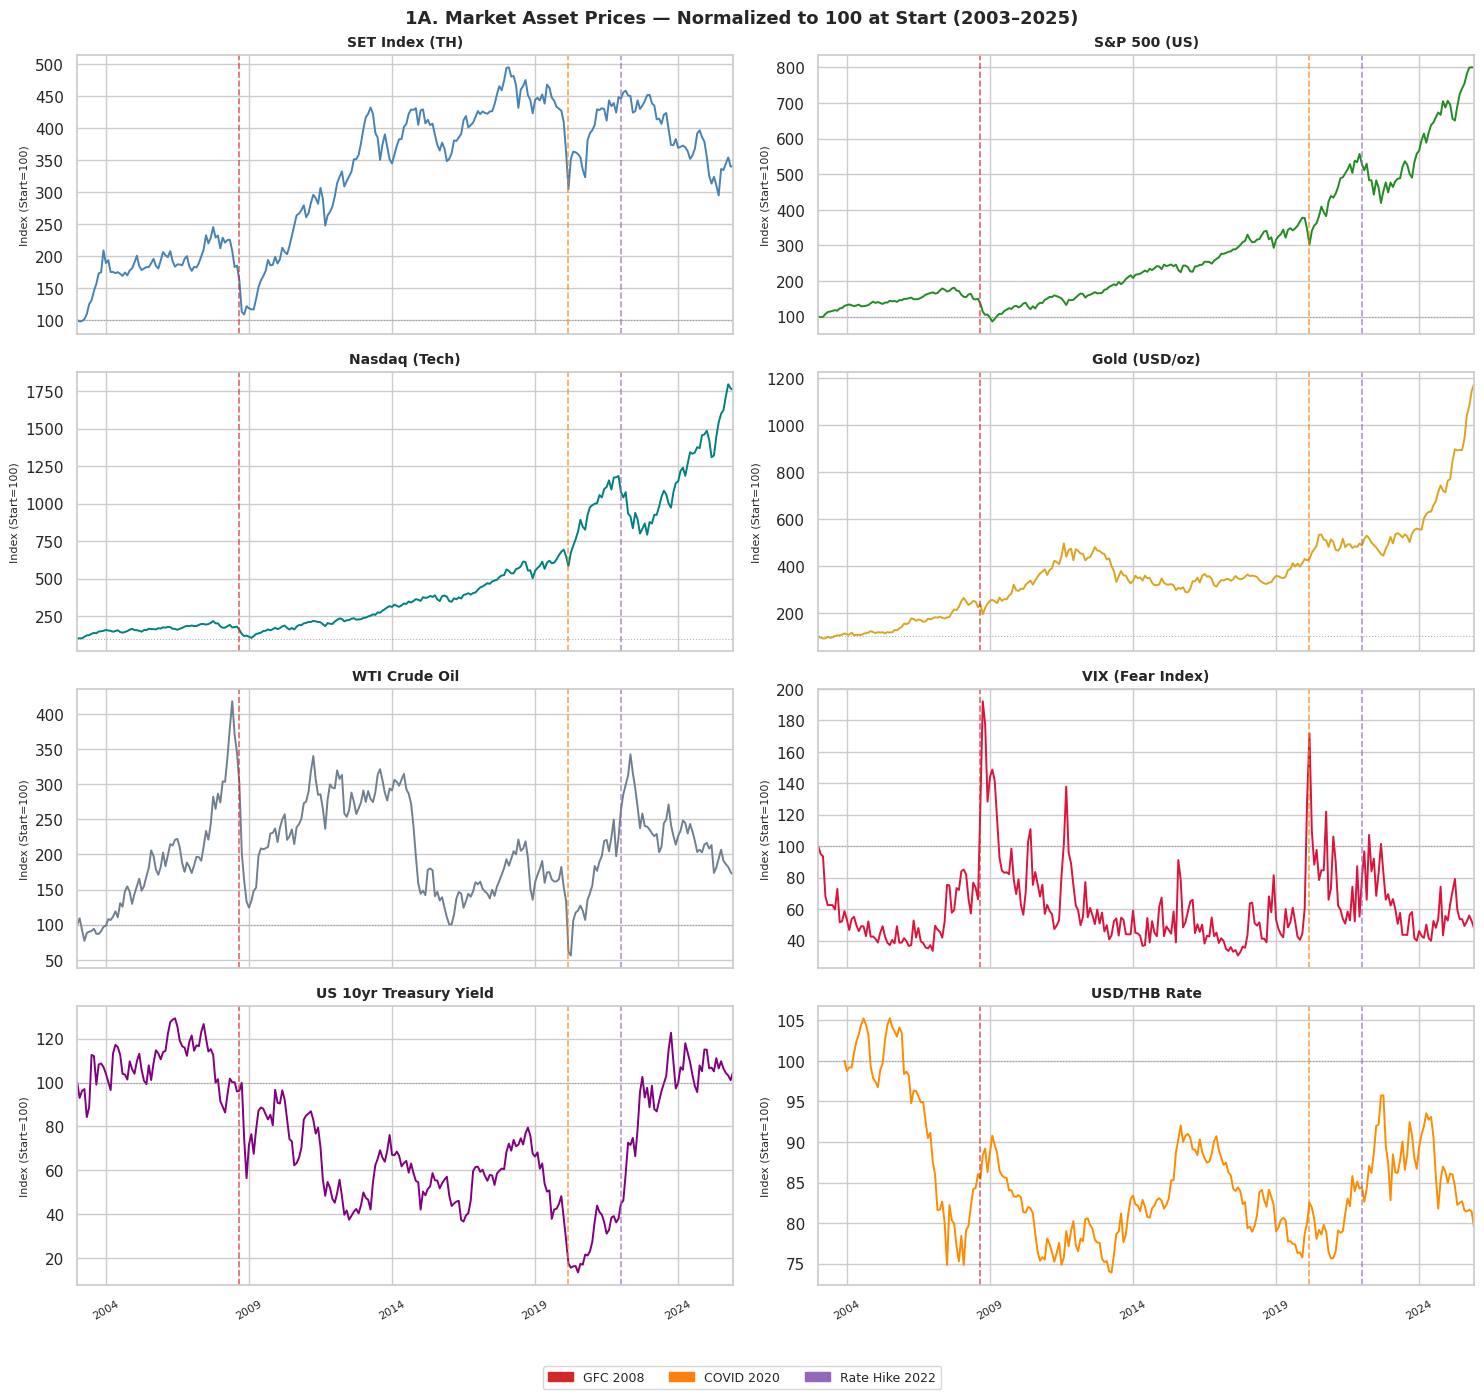

In [2]:
price_norm = unified[MARKET_PRC_COLS].copy()
for col in price_norm.columns:
    first_valid = price_norm[col].first_valid_index()
    if first_valid is not None:
        price_norm[col] = price_norm[col] / price_norm[col].loc[first_valid] * 100

PRICE_INFO = {
    'SET_index_price':        ('SET Index (TH)',       'steelblue'),
    'sp500_price':            ('S&P 500 (US)',          'forestgreen'),
    'nasdaq_price':           ('Nasdaq (Tech)',         'teal'),
    'gold_price':             ('Gold (USD/oz)',         'goldenrod'),
    'oil_price':              ('WTI Crude Oil',        'slategray'),
    'vix_price':              ('VIX (Fear Index)',     'crimson'),
    'us_10yr_treasury_price': ('US 10yr Treasury Yield','purple'),
    'USD_THB_price':          ('USD/THB Rate',         'darkorange'),
}

fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=True)
axes = axes.flatten()

for i, (col, (label, color)) in enumerate(PRICE_INFO.items()):
    ax = axes[i]
    price_norm[col].plot(ax=ax, color=color, linewidth=1.4)
    ax.axhline(100, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

    for evt_name, (evt_date, evt_color) in EVENTS.items():
        ax.axvline(pd.Timestamp(evt_date), color=evt_color, alpha=0.7,
                   linestyle='--', linewidth=1.2)

    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Index (Start=100)', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

# Legend for events
legend_patches = [mpatches.Patch(color=c, label=n.replace('\n', ' '))
                  for n, (_, c) in EVENTS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('1A. Market Asset Prices — Normalized to 100 at Start (2003–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### 1B. SET Index Monthly Return Heatmap (Year × Month)

แสดง monthly return (%) เป็น heatmap — ช่วยเห็นว่าเดือนไหน/ปีไหนตลาดขึ้น/ลง
- **เขียว** = positive return
- **แดง** = negative return
- ยิ่งเข้ม = magnitude สูง

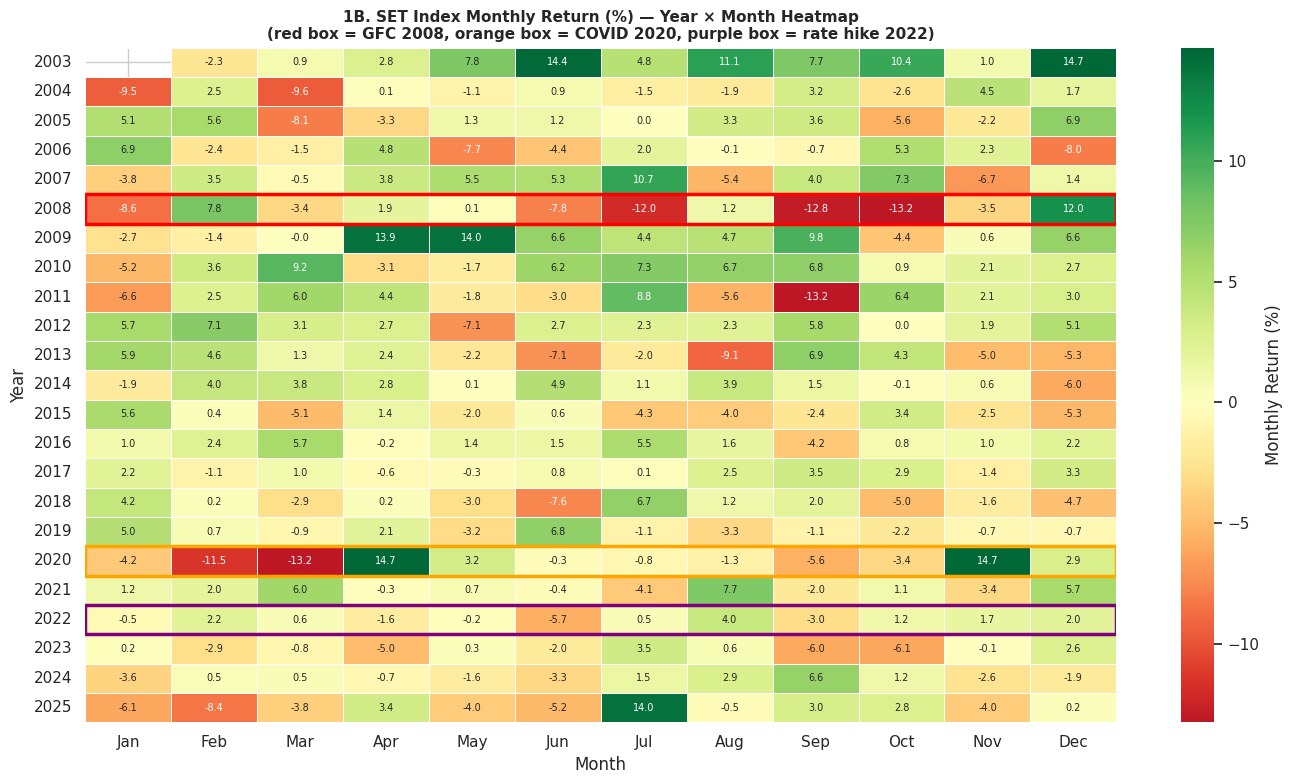

Best month  (avg): Jul   +2.07%
Worst month (avg): Mar   -0.51%
Best year   (sum): 2003   +73.2%
Worst year  (sum): 2008   -38.4%


In [3]:
ret_pct = (unified['SET_index_ret_m'] * 100).to_frame(name='ret')
ret_pct['year']  = ret_pct.index.year
ret_pct['month'] = ret_pct.index.month

pivot = ret_pct.pivot(index='year', columns='month', values='ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Monthly Return (%)'},
    annot_kws={'size': 7}
)

# Highlight GFC row (2008) and COVID row (2020)
years = list(pivot.index)
for yr, clr in [('2008', 'red'), ('2020', 'orange'), ('2022', 'purple')]:
    if int(yr) in years:
        idx = years.index(int(yr))
        ax.add_patch(plt.Rectangle((0, idx), 12, 1,
                     fill=False, edgecolor=clr, lw=2.5))

ax.set_title('1B. SET Index Monthly Return (%) — Year × Month Heatmap\n'
             '(red box = GFC 2008, orange box = COVID 2020, purple box = rate hike 2022)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

# Summary stats
print('Best month  (avg):',  pivot.mean().idxmax(), f'  +{pivot.mean().max():.2f}%')
print('Worst month (avg):', pivot.mean().idxmin(), f'  {pivot.mean().min():.2f}%')
print('Best year   (sum):',  int(pivot.sum(axis=1).idxmax()), f'  +{pivot.sum(axis=1).max():.1f}%')
print('Worst year  (sum):', int(pivot.sum(axis=1).idxmin()), f'  {pivot.sum(axis=1).min():.1f}%')

### 1C. FRED Monthly Indicators (Level)

ตัวแปร high-frequency รายเดือนจาก FRED — ทั้ง Thailand-specific และ US/Global indicators

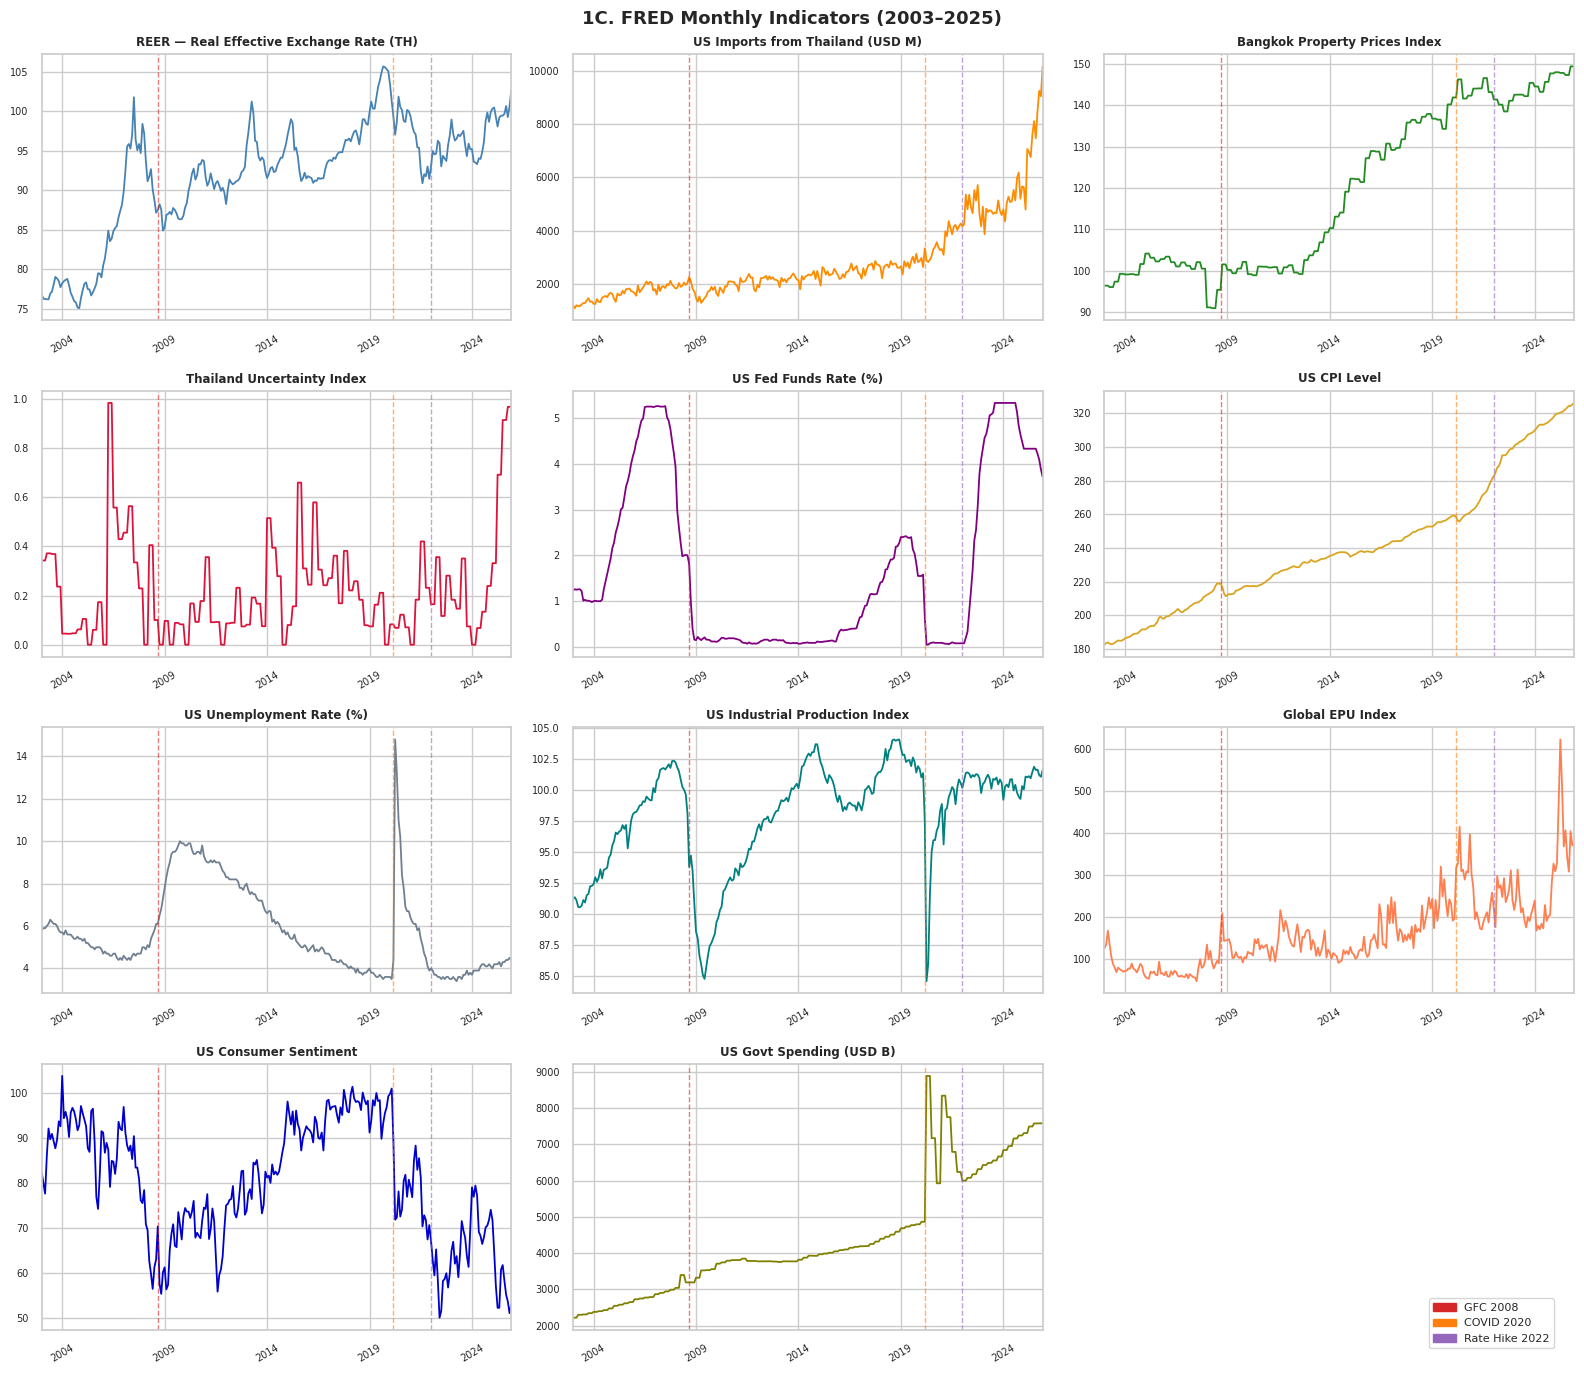

In [4]:
FRED_INFO = {
    'th_exchange_rate_real': ('REER — Real Effective Exchange Rate (TH)',  'steelblue'),
    'th_us_imports':         ('US Imports from Thailand (USD M)',           'darkorange'),
    'th_property_prices':    ('Bangkok Property Prices Index',              'forestgreen'),
    'th_uncertainty':        ('Thailand Uncertainty Index',                 'crimson'),
    'us_fed_funds_rate':     ('US Fed Funds Rate (%)',                      'purple'),
    'us_cpi_monthly':        ('US CPI Level',                              'goldenrod'),
    'us_unemployment':       ('US Unemployment Rate (%)',                   'slategray'),
    'us_industrial_prod':    ('US Industrial Production Index',             'teal'),
    'global_uncertainty':    ('Global EPU Index',                           'coral'),
    'us_consumer_sentiment': ('US Consumer Sentiment',                      'mediumblue'),
    'us_govt_spending':      ('US Govt Spending (USD B)',                   'olive'),
}

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=False)
axes = axes.flatten()

for i, (col, (label, color)) in enumerate(FRED_INFO.items()):
    ax = axes[i]
    unified[col].plot(ax=ax, color=color, linewidth=1.3)

    for evt_name, (evt_date, evt_color) in EVENTS.items():
        ax.axvline(pd.Timestamp(evt_date), color=evt_color, alpha=0.6,
                   linestyle='--', linewidth=1)

    ax.set_title(label, fontsize=8.5, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Hide unused subplot
axes[-1].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=n.replace('\n', ' '))
                  for n, (_, c) in EVENTS.items()]
fig.legend(handles=legend_patches, loc='lower right', fontsize=8,
           frameon=True, bbox_to_anchor=(0.98, 0.02))

plt.suptitle('1C. FRED Monthly Indicators (2003–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1D. Annual Macro Indicators — Thailand

ข้อมูล World Bank / IMF รายปี — แสดงเป็น bar + line เพื่อเห็น trend ระยะยาว

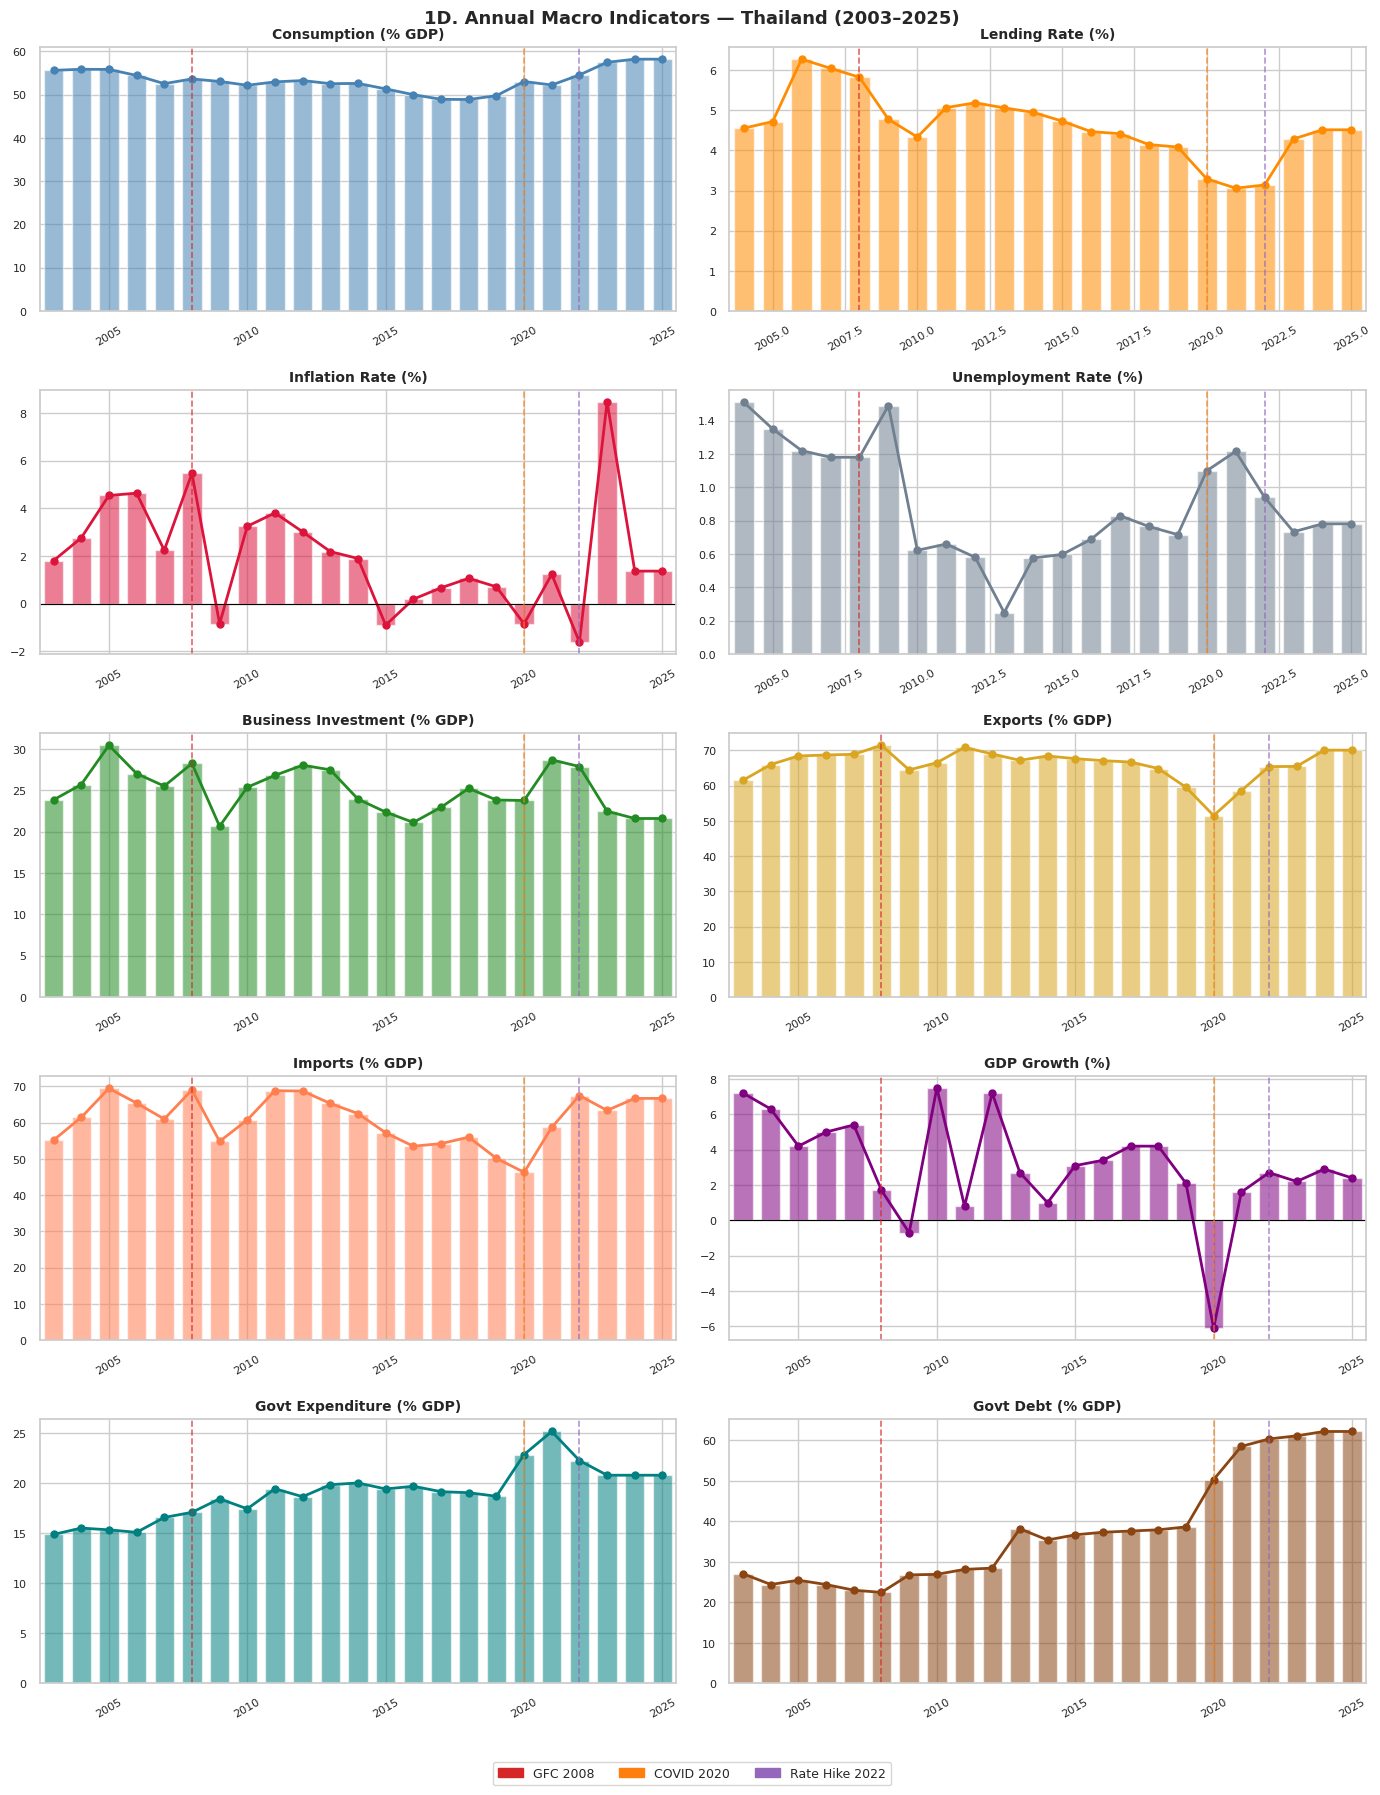

In [5]:
# Resample annual data back to yearly points for plotting
macro_annual = unified[MACRO_COLS].resample('YE').last()
macro_annual.index = macro_annual.index.year

MACRO_INFO = {
    'consumption_annual':     ('Consumption (% GDP)',           'steelblue'),
    'lending_rate_annual':    ('Lending Rate (%)',              'darkorange'),
    'inflation_annual':       ('Inflation Rate (%)',            'crimson'),
    'unemployment_annual':    ('Unemployment Rate (%)',         'slategray'),
    'business_invest_annual': ('Business Investment (% GDP)',   'forestgreen'),
    'exports_pct_gdp_annual': ('Exports (% GDP)',               'goldenrod'),
    'imports_pct_gdp_annual': ('Imports (% GDP)',               'coral'),
    'gdp_growth_annual':      ('GDP Growth (%)',                'purple'),
    'govt_expenditure_annual':('Govt Expenditure (% GDP)',      'teal'),
    'govt_debt_annual':       ('Govt Debt (% GDP)',             'saddlebrown'),
}

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

event_years = {'GFC 2008': (2008, 'tab:red'), 'COVID 2020': (2020, 'tab:orange'),
               'Rate Hike 2022': (2022, 'tab:purple')}

for i, (col, (label, color)) in enumerate(MACRO_INFO.items()):
    ax = axes[i]
    data = macro_annual[col].dropna()

    ax.bar(data.index, data.values, color=color, alpha=0.55, width=0.7)
    ax.plot(data.index, data.values, color=color, linewidth=2,
            marker='o', markersize=5)

    # Zero line for rate/growth vars
    if data.min() < 0:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

    for evt_name, (evt_year, evt_color) in event_years.items():
        if evt_year in data.index:
            ax.axvline(evt_year, color=evt_color, alpha=0.7,
                       linestyle='--', linewidth=1.2)

    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlim(data.index.min() - 0.5, data.index.max() + 0.5)

legend_patches = [mpatches.Patch(color=c, label=n)
                  for n, (_, c) in event_years.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('1D. Annual Macro Indicators — Thailand (2003–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

---
## 2. Distribution & Outlier Analysis

### 2A. Monthly Returns Distribution — Histogram + KDE

ดูรูปร่างการกระจายตัวของ monthly return แต่ละตัว:
- **Fat tails** = มี extreme events บ่อยกว่า normal distribution
- **Skewness** = การกระจายไม่สมมาตร
- เส้นสีแดง = normal distribution fit เพื่อเปรียบเทียบ

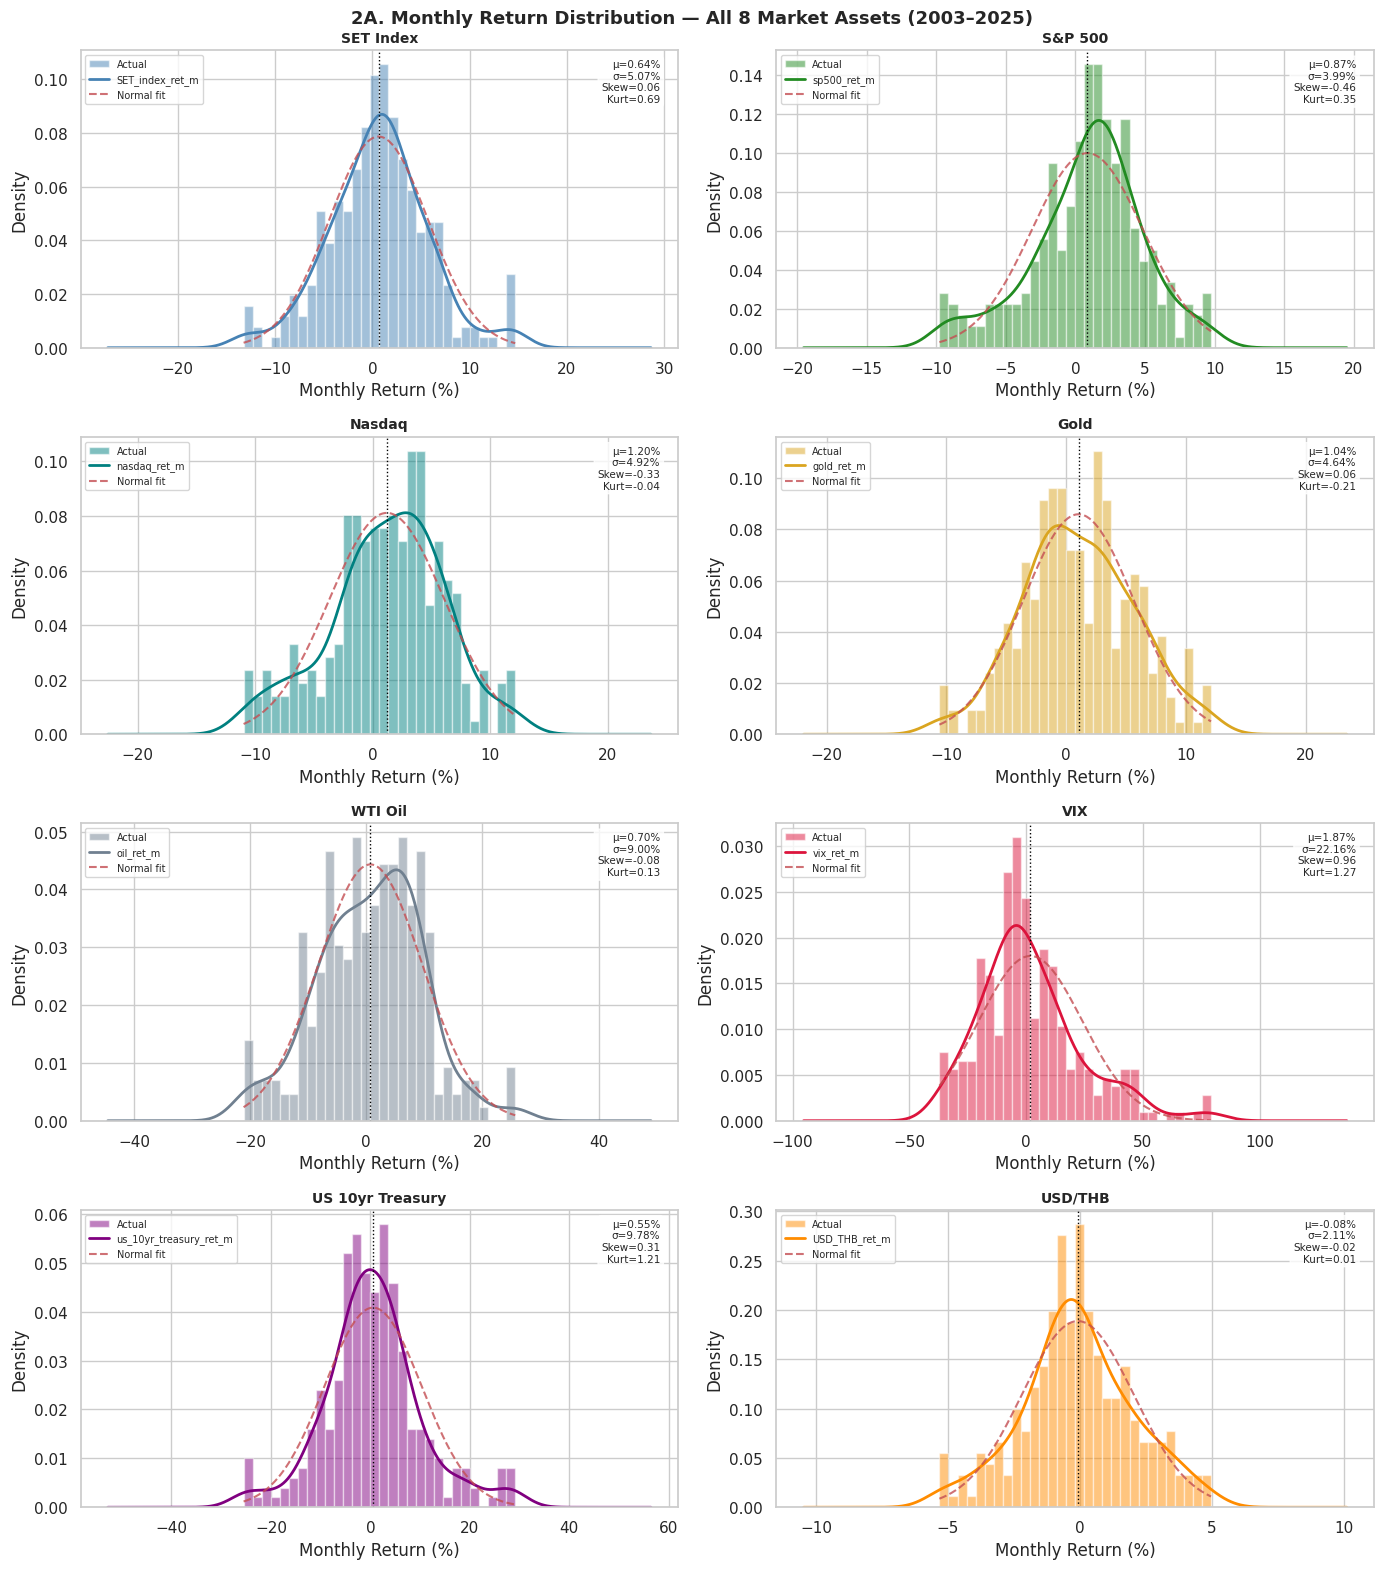

Distribution Stats Summary:
                  mean_%   std_%  skewness  excess_kurtosis   min_%   max_%
asset                                                                      
SET Index          0.642   5.074     0.064            0.694 -13.242  14.688
S&P 500            0.869   3.995    -0.457            0.353  -9.769   9.747
Nasdaq             1.198   4.918    -0.325           -0.043 -10.998  12.122
Gold               1.036   4.643     0.060           -0.215 -10.577  12.100
WTI Oil            0.701   8.999    -0.083            0.132 -21.123  25.640
VIX                1.870  22.164     0.958            1.267 -37.142  79.217
US 10yr Treasury   0.545   9.776     0.314            1.208 -25.491  29.137
USD/THB           -0.081   2.115    -0.020            0.015  -5.327   4.967

⚠️  |Kurtosis| > 1 → fat tails (extreme events more likely than normal)
⚠️  |Skew|    > 0.5 → asymmetric distribution


In [6]:
ret_data = unified[MARKET_RET_COLS].dropna(how='all') * 100  # convert to %

LABEL_MAP = {
    'SET_index_ret_m':        ('SET Index',        'steelblue'),
    'sp500_ret_m':            ('S&P 500',           'forestgreen'),
    'nasdaq_ret_m':           ('Nasdaq',            'teal'),
    'gold_ret_m':             ('Gold',              'goldenrod'),
    'oil_ret_m':              ('WTI Oil',           'slategray'),
    'vix_ret_m':              ('VIX',               'crimson'),
    'us_10yr_treasury_ret_m': ('US 10yr Treasury', 'purple'),
    'USD_THB_ret_m':          ('USD/THB',           'darkorange'),
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

stats_rows = []
for i, (col, (label, color)) in enumerate(LABEL_MAP.items()):
    ax = axes[i]
    series = ret_data[col].dropna()

    # Histogram + KDE
    ax.hist(series, bins=30, density=True, alpha=0.5, color=color, label='Actual')
    series.plot.kde(ax=ax, color=color, linewidth=2)

    # Normal fit overlay
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.min(), series.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r--', linewidth=1.5,
            alpha=0.8, label='Normal fit')

    ax.axvline(mu, color='black', linewidth=1, linestyle=':')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Monthly Return (%)')
    ax.legend(fontsize=7)

    # Stats annotation
    skew = stats.skew(series)
    kurt = stats.kurtosis(series)  # excess kurtosis
    ax.text(0.97, 0.97, f'μ={mu:.2f}%\nσ={sigma:.2f}%\nSkew={skew:.2f}\nKurt={kurt:.2f}',
            transform=ax.transAxes, fontsize=7.5,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    stats_rows.append({'asset': label, 'mean_%': mu, 'std_%': sigma,
                       'skewness': skew, 'excess_kurtosis': kurt,
                       'min_%': series.min(), 'max_%': series.max()})

plt.suptitle('2A. Monthly Return Distribution — All 8 Market Assets (2003–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_rows).set_index('asset').round(3)
print('Distribution Stats Summary:')
print(stats_df.to_string())
print('\n⚠️  |Kurtosis| > 1 → fat tails (extreme events more likely than normal)')
print('⚠️  |Skew|    > 0.5 → asymmetric distribution')

### 2B. Box Plots — Comparing Return Spread Across Assets

- **Box** = IQR (25th–75th percentile)
- **Line** = median
- **Whiskers** = 1.5×IQR
- **Dots** = outliers (months ที่ extreme)

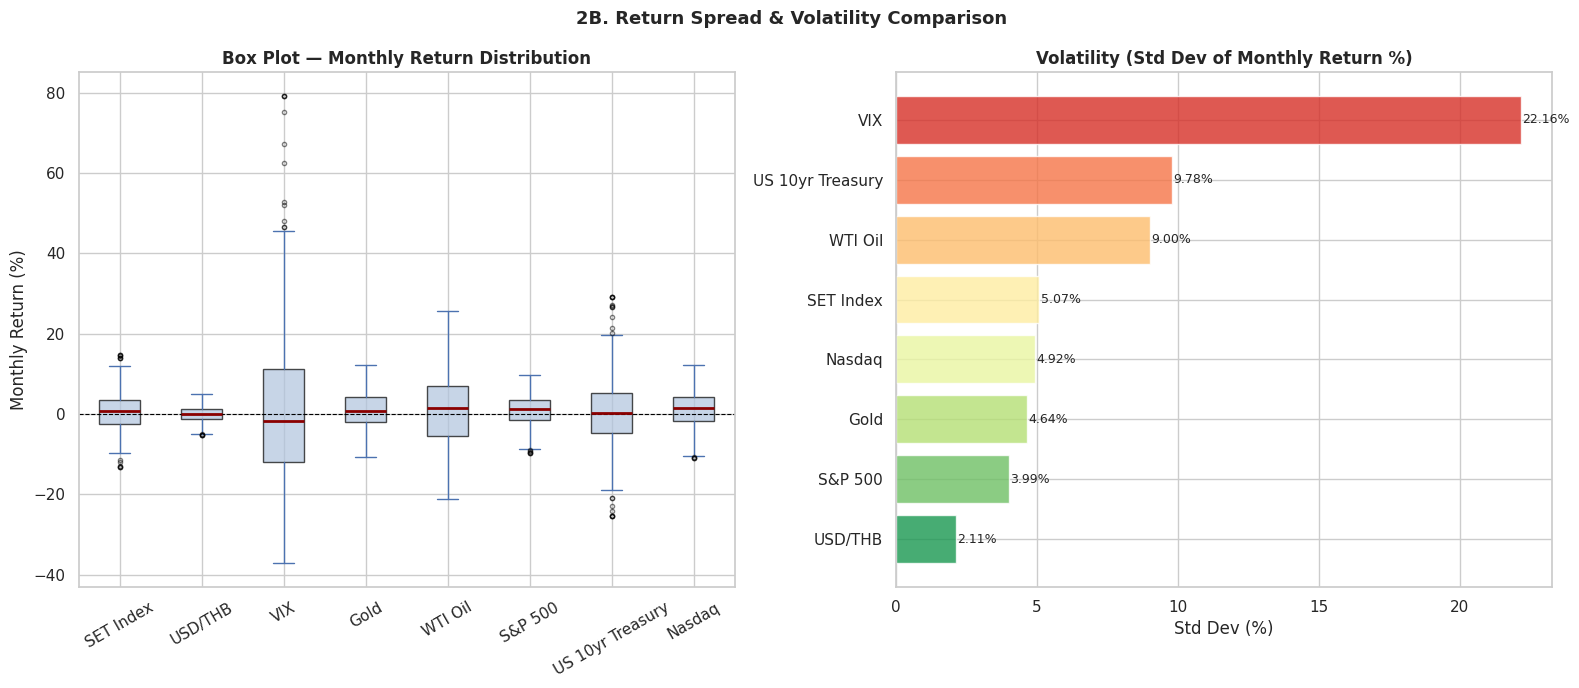

In [7]:
box_data = ret_data.copy()
box_data.columns = [LABEL_MAP[c][0] for c in box_data.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: box plot
box_data.plot.box(ax=axes[0], vert=True,
                  patch_artist=True, notch=False,
                  boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                  medianprops=dict(color='darkred', linewidth=2),
                  flierprops=dict(marker='o', markersize=3, alpha=0.5))
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Box Plot — Monthly Return Distribution', fontweight='bold')
axes[0].set_ylabel('Monthly Return (%)')
axes[0].tick_params(axis='x', rotation=30)

# Right: volatility comparison (std dev)
vols = box_data.std().sort_values(ascending=True)
colors_v = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(vols)))
axes[1].barh(vols.index, vols.values, color=colors_v, alpha=0.8)
for j, (idx, val) in enumerate(vols.items()):
    axes[1].text(val + 0.05, j, f'{val:.2f}%', va='center', fontsize=9)
axes[1].set_title('Volatility (Std Dev of Monthly Return %)', fontweight='bold')
axes[1].set_xlabel('Std Dev (%)')

plt.suptitle('2B. Return Spread & Volatility Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2C. Outlier Detection — Z-Score Analysis

หา **outlier months** ที่ extreme ที่สุดสำหรับ SET Index monthly return:
- **|Z| > 2.5** = outlier (~1.2% ของข้อมูล)
- แต่ละจุดสีแดง = เดือนที่ market เคลื่อนไหวผิดปกติ

จากนั้นทำ outlier summary ทุก asset

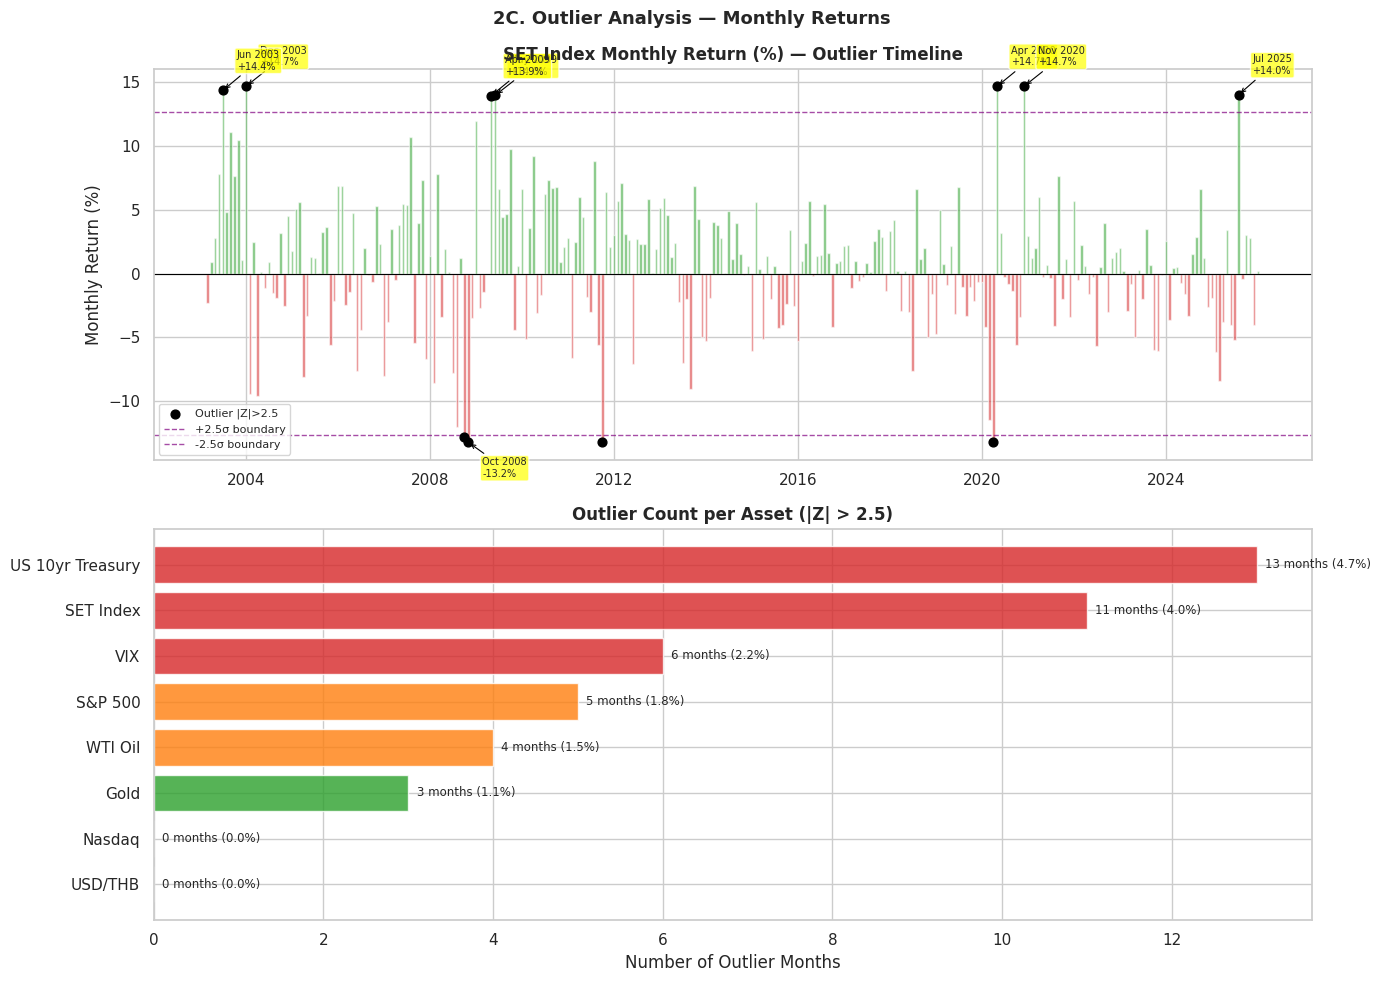


Outlier Summary Table:
           asset  n_months  n_outliers  pct_outlier  worst_month_%  best_month_%
US 10yr Treasury       275          13          4.7         -25.49         29.14
       SET Index       275          11          4.0         -13.24         14.69
             VIX       275           6          2.2         -37.14         79.22
         S&P 500       275           5          1.8          -9.77          9.75
         WTI Oil       275           4          1.5         -21.12         25.64
            Gold       275           3          1.1         -10.58         12.10
         USD/THB       264           0          0.0          -5.33          4.97
          Nasdaq       275           0          0.0         -11.00         12.12


In [8]:
Z_THRESH = 2.5

# --- Panel 1: SET Index outlier timeline ---
set_ret = ret_data['SET_index_ret_m'].dropna()
set_z   = (set_ret - set_ret.mean()) / set_ret.std()
outliers = set_ret[set_z.abs() > Z_THRESH]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Timeline
ax = axes[0]
ax.bar(set_ret.index, set_ret.values,
       color=['tab:red' if v < 0 else 'tab:green' for v in set_ret],
       alpha=0.6, width=20)
ax.scatter(outliers.index, outliers.values,
           color='black', zorder=5, s=40, label=f'Outlier |Z|>{Z_THRESH}')

# Annotate the most extreme ones
top_outliers = outliers.reindex(outliers.abs().nlargest(8).index)
for date, val in top_outliers.items():
    ax.annotate(f"{date.strftime('%b %Y')}\n{val:+.1f}%",
                xy=(date, val), xytext=(10, 15 if val > 0 else -25),
                textcoords='offset points', fontsize=7,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(Z_THRESH * set_ret.std(), color='purple', linestyle='--',
           linewidth=1, alpha=0.7, label=f'+{Z_THRESH}σ boundary')
ax.axhline(-Z_THRESH * set_ret.std(), color='purple', linestyle='--',
           linewidth=1, alpha=0.7, label=f'-{Z_THRESH}σ boundary')
ax.legend(fontsize=8)
ax.set_title('SET Index Monthly Return (%) — Outlier Timeline', fontweight='bold')
ax.set_ylabel('Monthly Return (%)')

# --- Panel 2: Outlier count per asset ---
ax2 = axes[1]
outlier_summary = []
for col in MARKET_RET_COLS:
    s = ret_data[col].dropna()
    z = (s - s.mean()) / s.std()
    n_out = (z.abs() > Z_THRESH).sum()
    worst = s[z == z.min()].values[0] if len(s) > 0 else np.nan
    best  = s[z == z.max()].values[0] if len(s) > 0 else np.nan
    outlier_summary.append({
        'asset':    LABEL_MAP[col][0],
        'n_months': len(s),
        'n_outliers': n_out,
        'pct_outlier': round(n_out / len(s) * 100, 1),
        'worst_month_%': round(worst, 2),
        'best_month_%':  round(best, 2),
    })

out_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=True)
colors_o = ['tab:red' if v > 5 else 'tab:orange' if v > 3 else 'tab:green'
             for v in out_df['n_outliers']]
ax2.barh(out_df['asset'], out_df['n_outliers'], color=colors_o, alpha=0.8)
for j, row in out_df.reset_index(drop=True).iterrows():
    ax2.text(row['n_outliers'] + 0.1, j,
             f"{row['n_outliers']} months ({row['pct_outlier']}%)",
             va='center', fontsize=8.5)
ax2.set_title(f'Outlier Count per Asset (|Z| > {Z_THRESH})', fontweight='bold')
ax2.set_xlabel('Number of Outlier Months')

plt.suptitle('2C. Outlier Analysis — Monthly Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nOutlier Summary Table:')
print(out_df.sort_values('n_outliers', ascending=False).to_string(index=False))

---
## 3. Missing Data & Annual → Monthly Forward-Fill

### 3A. Missing Data Heatmap — Unified Monthly Dataset

แสดงว่าแต่ละ column มีข้อมูลหายไปไหน และ pattern การหายเป็นแบบใด
- **สีขาว/อ่อน** = missing
- **สีเข้ม** = มีข้อมูล

> ⚠️ **หมายเหตุ:** ตัวแปร `_annual` ที่เห็นว่า "ไม่หาย" ส่วนใหญ่เป็นเพราะถูก forward-fill แล้ว ไม่ใช่ว่ามีข้อมูลรายเดือนจริงๆ — ดูรายละเอียดใน Section 3B

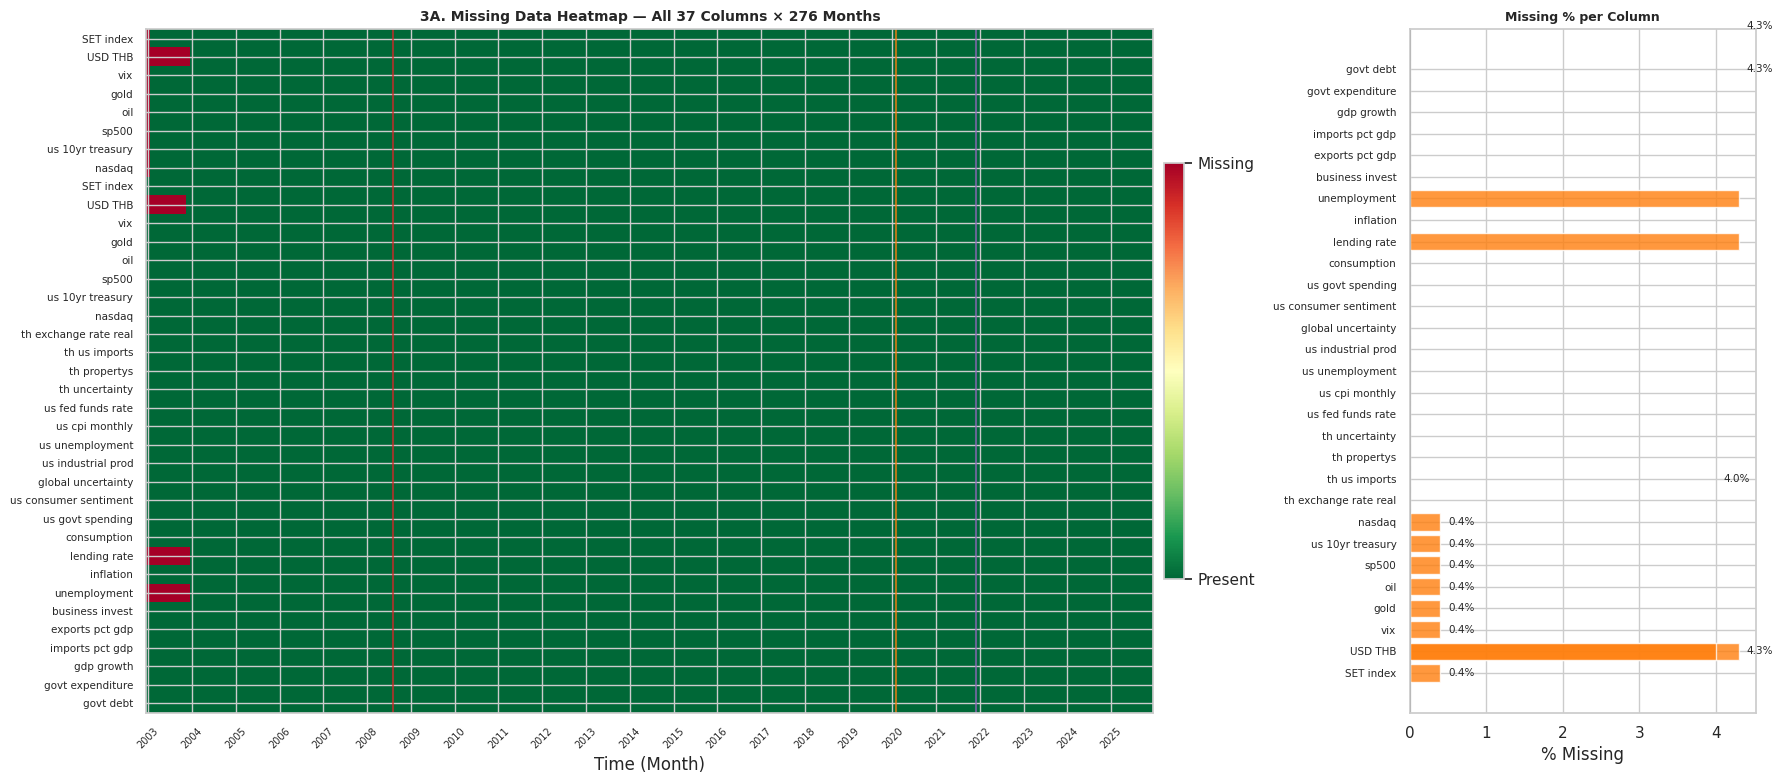

Columns with missing data:
USD THB             4.3
unemployment        4.3
lending rate        4.3
USD THB             4.0
SET index           0.4
vix                 0.4
gold                0.4
us 10yr treasury    0.4
sp500               0.4
oil                 0.4
nasdaq              0.4


In [9]:
# Build binary missing matrix (True = missing)
miss_matrix = unified.isnull().astype(int)

# Short column labels
short_labels = [
    c.replace('_ret_m','').replace('_price','').replace('_annual','').replace('_',' ')
    for c in unified.columns
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                          gridspec_kw={'width_ratios': [3, 1]})

# Left: heatmap over time
ax = axes[0]
im = ax.imshow(miss_matrix.T.values, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=1, interpolation='none')

# X-axis: years
year_ticks = unified.index[unified.index.month == 1]
year_pos   = [list(unified.index).index(d) for d in year_ticks]
ax.set_xticks(year_pos)
ax.set_xticklabels([d.year for d in year_ticks], rotation=45, fontsize=7)

# Y-axis: column names
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=7.5)

# Event lines
for evt_name, (evt_date, evt_color) in EVENTS.items():
    evt_idx = unified.index.get_indexer([pd.Timestamp(evt_date)], method='nearest')[0]
    ax.axvline(evt_idx, color=evt_color, linewidth=1.5, alpha=0.7)

# Color bar
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Present', 'Missing'])

ax.set_title('3A. Missing Data Heatmap — All 37 Columns × 276 Months',
             fontweight='bold', fontsize=10)
ax.set_xlabel('Time (Month)')

# Right: % missing bar chart
ax2 = axes[1]
miss_pct = (unified.isnull().sum() / len(unified) * 100).round(1)
miss_pct.index = short_labels
colors_m = ['tab:red' if v > 5 else 'tab:orange' if v > 0 else 'tab:green'
             for v in miss_pct]
ax2.barh(miss_pct.index, miss_pct.values, color=colors_m, alpha=0.8)
for j, (idx, val) in enumerate(miss_pct.items()):
    if val > 0:
        ax2.text(val + 0.1, j, f'{val}%', va='center', fontsize=7.5)
ax2.set_title('Missing % per Column', fontweight='bold', fontsize=9)
ax2.set_xlabel('% Missing')
ax2.axvline(0, color='black', linewidth=0.5)
ax2.tick_params(axis='y', labelsize=7.5)

plt.tight_layout()
plt.show()

missing_summary = miss_pct[miss_pct > 0].sort_values(ascending=False)
print('Columns with missing data:')
print(missing_summary.to_string())

### 3B. Annual → Monthly Forward-Fill Effect

**ปัญหา:** ข้อมูล macro รายปี (เช่น unemployment, GDP growth) ถูก forward-fill เข้า monthly dataset
→ ค่าเหมือนกัน 12 เดือนติดกัน = **step-function pattern**

**ผลกระทบต่อ model:**
- Correlation กับ monthly variables อาจ **underestimate** ของจริง
- ห้าม interpret ว่าตัวแปรเหล่านี้มีข้อมูลรายเดือนจริงๆ
- ควร **lag 1 ปี** ก่อนใช้ใน model (ค่าปีนี้ไม่รู้จนสิ้นปี)

กราฟซ้าย = monthly granularity | กราฟขวา = annual data points จริงๆ

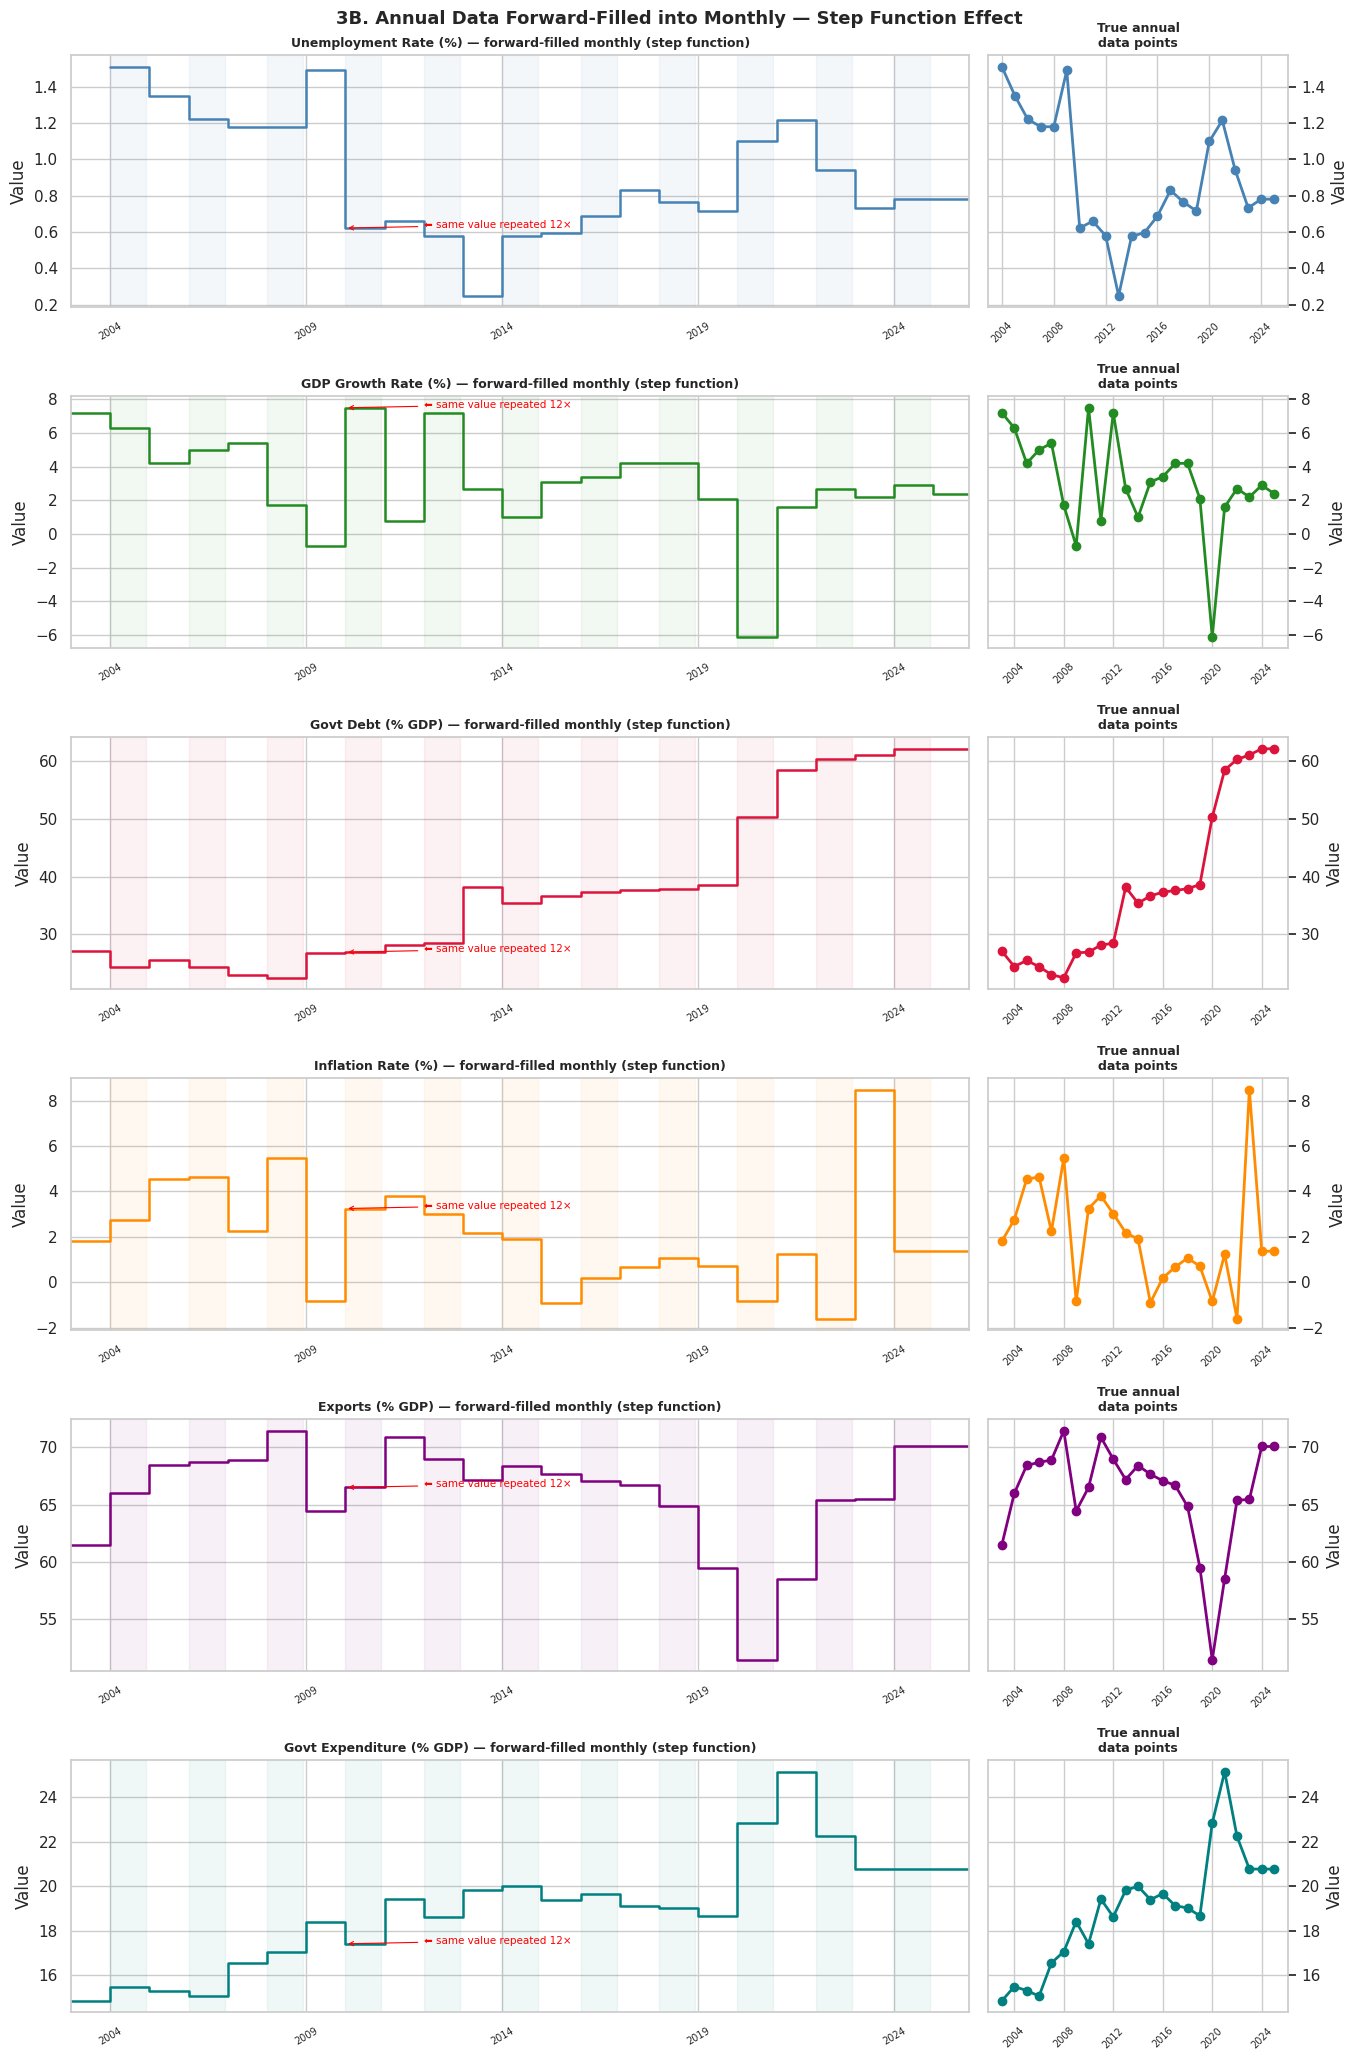

⚠️  Key takeaway: annual macro variables change ONCE per year in this dataset.
    Do NOT treat them as having monthly variation when modeling.
    When building models: use annual aggregation OR apply 1-year lag to avoid look-ahead bias.


In [10]:
DEMO_VARS = {
    'unemployment_annual':     ('Unemployment Rate (%)',         'steelblue'),
    'gdp_growth_annual':       ('GDP Growth Rate (%)',           'forestgreen'),
    'govt_debt_annual':        ('Govt Debt (% GDP)',             'crimson'),
    'inflation_annual':        ('Inflation Rate (%)',            'darkorange'),
    'exports_pct_gdp_annual':  ('Exports (% GDP)',               'purple'),
    'govt_expenditure_annual': ('Govt Expenditure (% GDP)',      'teal'),
}

fig, axes = plt.subplots(len(DEMO_VARS), 2,
                          figsize=(14, 3.5 * len(DEMO_VARS)),
                          gridspec_kw={'width_ratios': [3, 1]})

for i, (col, (label, color)) in enumerate(DEMO_VARS.items()):
    monthly_series = unified[col]   # forward-filled into monthly
    annual_series  = unified[col].resample('YE').last()  # true annual points
    annual_series.index = annual_series.index.to_period('Y').to_timestamp()

    # Left: monthly (step function)
    ax_l = axes[i][0]
    monthly_series.plot(ax=ax_l, color=color, linewidth=1.8,
                        drawstyle='steps-post')
    ax_l.set_title(f'{label} — forward-filled monthly (step function)',
                   fontsize=9, fontweight='bold')
    ax_l.set_ylabel('Value')
    ax_l.tick_params(axis='x', rotation=30, labelsize=7)

    # Shade "repeated" zones
    for yr in range(2003, 2026):
        start = pd.Timestamp(f'{yr}-01-01')
        end   = pd.Timestamp(f'{yr}-12-31')
        if yr % 2 == 0:
            ax_l.axvspan(start, end, alpha=0.06, color=color)

    ax_l.annotate('⬅ same value repeated 12×', xy=(pd.Timestamp('2010-01-01'), monthly_series.loc['2010':'2010'].mean()),
                  xytext=(pd.Timestamp('2012-01-01'), monthly_series.loc['2010':'2010'].mean()),
                  fontsize=7.5, color='red',
                  arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    # Right: annual data points only
    ax_r = axes[i][1]
    true_annual = annual_series.dropna()
    ax_r.plot(true_annual.index, true_annual.values,
              color=color, linewidth=2, marker='o', markersize=6)
    ax_r.set_title('True annual\ndata points', fontsize=9, fontweight='bold')
    ax_r.tick_params(axis='x', rotation=45, labelsize=7)
    ax_r.set_ylabel('Value')
    ax_r.yaxis.set_label_position('right')
    ax_r.yaxis.tick_right()

plt.suptitle('3B. Annual Data Forward-Filled into Monthly — Step Function Effect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('⚠️  Key takeaway: annual macro variables change ONCE per year in this dataset.')
print('    Do NOT treat them as having monthly variation when modeling.')
print('    When building models: use annual aggregation OR apply 1-year lag to avoid look-ahead bias.')

### 3C. Data Frequency Audit — ตารางสรุป Data Source ของทุก Column

แสดงว่าแต่ละตัวแปรมาจากไหน, frequency จริงคืออะไร, และ coverage % ใน unified dataset

In [11]:
audit_rows = [
    # Market daily → resampled monthly
    ('SET_index_ret_m',        'yfinance (SET.BK)',  'daily→monthly', 'Factor 0: Target',          'ret'),
    ('USD_THB_ret_m',          'yfinance (THB=X)',   'daily→monthly', 'Factor 6: Trade/FX',        'ret'),
    ('vix_ret_m',              'yfinance (^VIX)',    'daily→monthly', 'Factor 7: Geopolitical',    'ret'),
    ('gold_ret_m',             'yfinance (GC=F)',    'daily→monthly', 'Factor 7: Safe haven',      'ret'),
    ('oil_ret_m',              'yfinance (CL=F)',    'daily→monthly', 'Factor 6: Supply chain',    'ret'),
    ('sp500_ret_m',            'yfinance (^GSPC)',   'daily→monthly', 'Factor 6: Global demand',   'ret'),
    ('us_10yr_treasury_ret_m', 'yfinance (^TNX)',    'daily→monthly', 'Factor 2: Interest rate',   'ret'),
    ('nasdaq_ret_m',           'yfinance (^IXIC)',   'daily→monthly', 'Factor 8: Technology',      'ret'),
    ('SET_index_price',        'yfinance (SET.BK)',  'daily→monthly', 'Factor 0: Target',          'price'),
    ('USD_THB_price',          'yfinance (THB=X)',   'daily→monthly', 'Factor 6: Trade/FX',        'price'),
    ('vix_price',              'yfinance (^VIX)',    'daily→monthly', 'Factor 7: Geopolitical',    'price'),
    ('gold_price',             'yfinance (GC=F)',    'daily→monthly', 'Factor 7: Safe haven',      'price'),
    ('oil_price',              'yfinance (CL=F)',    'daily→monthly', 'Factor 6: Supply chain',    'price'),
    ('sp500_price',            'yfinance (^GSPC)',   'daily→monthly', 'Factor 6: Global demand',   'price'),
    ('us_10yr_treasury_price', 'yfinance (^TNX)',    'daily→monthly', 'Factor 2: Interest rate',   'price'),
    ('nasdaq_price',           'yfinance (^IXIC)',   'daily→monthly', 'Factor 8: Technology',      'price'),
    # FRED monthly (true monthly)
    ('th_exchange_rate_real',  'FRED (RBTHBIS)',     'monthly',       'Factor 6: Trade',           'level'),
    ('th_us_imports',          'FRED (IMP5490)',     'monthly',       'Factor 6: US demand',       'level'),
    ('th_property_prices',     'FRED (QTHR628BIS)',  'quarterly→M',   'Factor 1: Consumption',     'level'),
    ('th_uncertainty',         'FRED (WUITHA)',      'quarterly→M',   'Factor 7: Geopolitical',    'level'),
    ('us_fed_funds_rate',      'FRED (FEDFUNDS)',    'monthly',       'Factor 2: Interest rate',   'level'),
    ('us_cpi_monthly',         'FRED (CPIAUCSL)',    'monthly',       'Factor 3: Inflation',       'level'),
    ('us_unemployment',        'FRED (UNRATE)',      'monthly',       'Factor 4: Unemployment',    'level'),
    ('us_industrial_prod',     'FRED (INDPRO)',      'monthly',       'Factor 5: Investment',      'level'),
    ('global_uncertainty',     'FRED (GEPUCURRENT)', 'monthly',      'Factor 7: Geopolitical',    'level'),
    ('us_consumer_sentiment',  'FRED (UMCSENT)',     'monthly',       'Factor 1/8: Sentiment',     'level'),
    ('us_govt_spending',       'FRED (FGEXPND)',     'quarterly→M',   'Factor 9: Gov Policy',      'level'),
    # Annual macro (forward-filled!)
    ('consumption_annual',     'World Bank',         'annual→M (ffill)','Factor 1: Consumption',  'level'),
    ('lending_rate_annual',    'World Bank',         'annual→M (ffill)','Factor 2: Interest rate', 'level'),
    ('inflation_annual',       'World Bank/IMF',     'annual→M (ffill)','Factor 3: Inflation',     'level'),
    ('unemployment_annual',    'World Bank/IMF',     'annual→M (ffill)','Factor 4: Unemployment',  'level'),
    ('business_invest_annual', 'World Bank',         'annual→M (ffill)','Factor 5: Investment',    'level'),
    ('exports_pct_gdp_annual', 'World Bank',         'annual→M (ffill)','Factor 6: Trade',         'level'),
    ('imports_pct_gdp_annual', 'World Bank',         'annual→M (ffill)','Factor 6: Trade',         'level'),
    ('gdp_growth_annual',      'IMF DataMapper',     'annual→M (ffill)','Factor 8: GDP proxy',     'level'),
    ('govt_expenditure_annual','World Bank',         'annual→M (ffill)','Factor 9: Gov Policy',    'level'),
    ('govt_debt_annual',       'World Bank',         'annual→M (ffill)','Factor 9: Gov Policy',    'level'),
]

audit_df = pd.DataFrame(audit_rows,
                         columns=['column', 'source', 'true_frequency', 'factor', 'type'])
audit_df['missing_%'] = audit_df['column'].map(
    lambda c: round(unified[c].isnull().sum() / len(unified) * 100, 1) if c in unified.columns else None
)
audit_df['n_unique_annual_vals'] = audit_df['column'].map(
    lambda c: unified[c].resample('YE').last().notna().sum() if c in unified.columns else None
)

print('Data Frequency Audit — All 37 Columns in unified_monthly.csv')
print('=' * 100)
print(audit_df[['column','source','true_frequency','factor','missing_%']].to_string(index=False))

# Summary
freq_summary = audit_df.groupby('true_frequency')['column'].count().reset_index()
freq_summary.columns = ['frequency', 'n_columns']
print('\n📊 Frequency breakdown:')
print(freq_summary.sort_values('n_columns', ascending=False).to_string(index=False))
print('\n⚠️  annual→M (ffill) columns: treat as annual data in models!')

Data Frequency Audit — All 37 Columns in unified_monthly.csv
                 column             source   true_frequency                  factor  missing_%
        SET_index_ret_m  yfinance (SET.BK)    daily→monthly        Factor 0: Target        0.4
          USD_THB_ret_m   yfinance (THB=X)    daily→monthly      Factor 6: Trade/FX        4.3
              vix_ret_m    yfinance (^VIX)    daily→monthly  Factor 7: Geopolitical        0.4
             gold_ret_m    yfinance (GC=F)    daily→monthly    Factor 7: Safe haven        0.4
              oil_ret_m    yfinance (CL=F)    daily→monthly  Factor 6: Supply chain        0.4
            sp500_ret_m   yfinance (^GSPC)    daily→monthly Factor 6: Global demand        0.4
 us_10yr_treasury_ret_m    yfinance (^TNX)    daily→monthly Factor 2: Interest rate        0.4
           nasdaq_ret_m   yfinance (^IXIC)    daily→monthly    Factor 8: Technology        0.4
        SET_index_price  yfinance (SET.BK)    daily→monthly        Factor 0: Target 

---
## Summary & Key Findings

| Section | Findings |
|---|---|
| **1A** | Gold และ Nasdaq growth มากกว่า SET อย่างชัดเจนในรอบ 20 ปี — SET underperform global peers |
| **1B** | ปีที่ market ตกหนักที่สุด = 2008 (GFC) และ 2020 (COVID) — กลับมาได้เร็วทั้งสองครั้ง |
| **1C** | US Fed Funds Rate พุ่งขึ้น 2022-2023 ชัดเจน — ส่งผลต่อทุก EM market รวม SET |
| **1D** | GDP Growth ไทยหด -6.1% ปี 2020 (worst in dataset) — ฟื้นตัวช้ากว่า peers |
| **2A** | VIX มี kurtosis สูงมาก (fat tails) — เหตุการณ์ panic เกิดรุนแรงกว่าที่ normal dist คาด |
| **2B** | Oil มี volatility สูงสุด, US 10yr Treasury ต่ำสุด |
| **2C** | SET outlier months ส่วนใหญ่ตรงกับ GFC 2008 และ COVID 2020 — events ที่รู้อยู่แล้ว |
| **3A** | Missing data น้อยมาก (<5%) ยกเว้น USD/THB ช่วงแรก |
| **3B** | Annual variables ถูก forward-fill เป็น step-function — ห้ามใช้เป็น monthly feature โดยตรง |
| **3C** | 10 columns จาก 37 เป็น annual→monthly (ffill) — ต้อง lag ก่อนใช้ใน model |

---
**Next:** `02_eda_rolling.ipynb` — Rolling statistics, regime detection, และ stationarity tests (ADF) ก่อน build model